# Fake Face Detection

## 1) Import Libraries

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

## 2) Define Dataset Paths & Image Size

In [2]:
DATASET_PATH = "/kaggle/input/real-and-fake-face-detection/real_and_fake_face"

REAL_PATH = os.path.join(DATASET_PATH, "training_real")
FAKE_PATH = os.path.join(DATASET_PATH, "training_fake")

IMG_SIZE = 224

## 3) Load & Label Images

In [4]:
def load_images_from_folder(folder, label):
    images = []
    labels = []

    for filename in os.listdir(folder):
        img_path = os.path.join(folder, filename)

        try:
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            images.append(img)
            labels.append(label)
        except:
            pass

    return images, labels


real_images, real_labels = load_images_from_folder(REAL_PATH, 0)
fake_images, fake_labels = load_images_from_folder(FAKE_PATH, 1)

X = np.array(real_images + fake_images)
y = np.array(real_labels + fake_labels)

print("Total images:", len(X))
print("Real images:", len(real_images))
print("Fake images:", len(fake_images))

Total images: 2041
Real images: 1081
Fake images: 960


## 4) Normalize & Split Data

In [5]:
X = X / 255.0 

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Validation samples:", X_val.shape)

Training samples: (1632, 224, 224, 3)
Validation samples: (409, 224, 224, 3)


## 5) Quick Visual Check

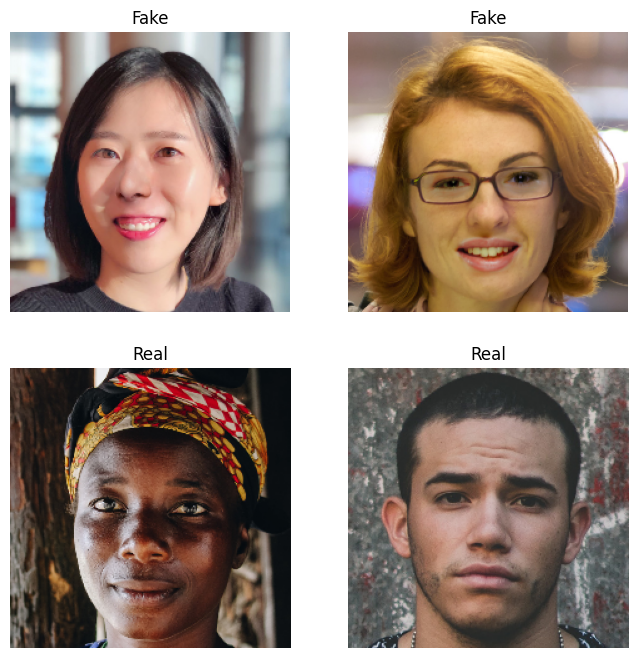

In [6]:
plt.figure(figsize=(8,8))

for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(X_train[i])
    plt.title("Fake" if y_train[i] == 1 else "Real")
    plt.axis("off")

plt.show()
